# Ejercicios de histogramas y boxplots (Core)

En esta actividad, utilizaremos el dataset «World Happiness Report» de Kaggle, que contiene información sobre la felicidad en diferentes países del mundo. Este dataset incluye variables como el puntaje de felicidad, el PIB per cápita, la expectativa de vida saludable, la libertad, la generosidad, entre otras.

Puedes descargar el dataset desde el siguiente enlace: [World Happiness Report.](https://www.kaggle.com/datasets/unsdsn/world-happiness)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

* CARGAMOS LOS DATOS A DATAFRAMES INDIVIDUALES POR AÑO

In [2]:
df2015 = pd.read_csv('../data/whr/2015.csv')
df2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

In [3]:
df2016 = pd.read_csv('../data/whr/2016.csv')
df2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    object 
 1   Region                         157 non-null    object 
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    flo

In [4]:
df2017 = pd.read_csv('../data/whr/2017.csv')
df2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    object 
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 

In [5]:
df2018 = pd.read_csv('../data/whr/2018.csv')
df2018.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     155 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [6]:
df2019 = pd.read_csv('../data/whr/2019.csv')
df2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


---
* Ningun set de datos presenta valores nulos
* Como las columnas cambian a lo largo del tiempo, se realizaran cambios como modificar nombres, eliminar columnas que no se usan en diferentes años.
* Se les agregara una columna nueva con el año respectivo
* Se concatenaran ambas en un solo dataframe para poder trabajar con el

---

In [7]:
#SE CREA UN DICCIONARIO CON TODAS LAS VARIANTES DE NOMBRES PRESENTES Y SU NOMBRE NUEVO DE CADA COLUMNA
nuevosNombres = {
    'Country': 'Pais',
    'Country or region': 'Pais',
    'Region': 'Region',
    'Happiness Rank': 'Ranking',
    'Happiness.Rank': 'Ranking',
    'Overall rank': 'Ranking',
    'Happiness Score': 'Puntaje_Felicidad',
    'Happiness.Score': 'Puntaje_Felicidad',
    'Score': 'Puntaje_Felicidad',
    'Economy (GDP per Capita)': 'PIBpc',
    'Economy..GDP.per.Capita.': 'PIBpc',
    'GDP per capita': 'PIBpc',
    'GDP per Capita': 'PIBpc',
    'Family': 'Apoyo_Social',
    'Social Support': 'Apoyo_Social',
    'Social support': 'Apoyo_Social',
    'Health (Life Expectancy)': 'Esperanza_Vida',
    'Healthy life expectancy': 'Esperanza_Vida',
    'Health..Life.Expectancy.': 'Esperanza_Vida',
    'Freedom': 'Libertad',
    'Freedom to make life choices': 'Libertad',
    'Trust (Government Corruption)': 'Percepcion_Corrupcion',
    'Perceptions of corruption': 'Percepcion_Corrupcion',
    'Trust..Government.Corruption.': 'Percepcion_Corrupcion',
    'Generosity': 'Generosidad'
}

In [8]:
#SE CREA UNA FUNCION PARA RENOMBRAR TODAS LAS COLUMNAS SEGUN EL DICCIONARIO CREADO
def RenombrarColumnas(lista_dfs, nuevosNombres):
    return [d.rename(columns=nuevosNombres) for d in lista_dfs]

# SE APLICA LA FUNCION:
df2015, df2016, df2017, df2018, df2019 = RenombrarColumnas([df2015, df2016, df2017, df2018, df2019], nuevosNombres)

In [9]:
#SE CREA UNA NUEVA COLUMNA CON LOS AÑOS DE LOS DATOS
#SE CREA UNA LISTA DE DATAFRAMES Y LOS AÑOS CORRESPONDIENTE
lista_dfs = [df2015, df2016, df2017, df2018, df2019]
años = range(2015, 2020)

#CON UN CICLO FOR SE AGREGA EL AÑO A CADA DATAFRAME
for df, año in zip(lista_dfs, años):
    df['año'] = año

In [10]:
#ELIMINAMOS COLUMNAS QUE CAMBIAN O DESAPARECEN CON LOS AÑOS
paraEliminar = ['Dystopia.Residual', 'Dystopia Residual', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Whisker.high', 'Whisker.low', 'Standard Error']

#USANDO EL ESQUELETO DE LA FUNCION RENOMBRAR, MODIFICAMOS PARA ELIMINAR LAS COLUMNAS EN LA LISTA
def EliminarColumnas(lista_dfs, borrar):
    return [d.drop(columns=borrar, errors='ignore') for d in lista_dfs]

df2015, df2016, df2017, df2018, df2019 = EliminarColumnas([df2015, df2016, df2017, df2018, df2019], paraEliminar)

In [11]:
#CREAMOS UN DATASET QUE AGRUPE TODOS LOS DATAFRAMES ANUALES PARA GRAFICAR
df = pd.concat([df2015, df2016, df2017, df2018, df2019], ignore_index=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Pais                   782 non-null    object 
 1   Region                 315 non-null    object 
 2   Ranking                782 non-null    int64  
 3   Puntaje_Felicidad      782 non-null    float64
 4   PIBpc                  782 non-null    float64
 5   Apoyo_Social           782 non-null    float64
 6   Esperanza_Vida         782 non-null    float64
 7   Libertad               782 non-null    float64
 8   Percepcion_Corrupcion  781 non-null    float64
 9   Generosidad            782 non-null    float64
 10  año                    782 non-null    int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 67.3+ KB


---
* Vemos que Region tiene valores nulos porque fue una columna que dejo de aparecer en el tiempo, siendo sustituida por pais. Pero me interesa ocuparla para graficar, asi que buscamos rellenar
* al revisar el contenido del dataframe, vemos que existen paises que cambian de nombre, y tambien paises que se van incorporando al estudio que antes no existian. Asi que se busca arreglar eso tambien
---

In [13]:
df.sample(8)

,Pais,Region,Ranking,Puntaje_Felicidad,PIBpc,Apoyo_Social,Esperanza_Vida,Libertad,Percepcion_Corrupcion,Generosidad,año
357,Nicaragua,NaN,43,6.071,0.737299,1.287216,0.653096,0.447552,0.130688,0.301674,2017
737,Somalia,NaN,112,4.668,0.000000,0.698000,0.268000,0.559000,0.270000,0.243000,2019
646,United Arab Emirates,NaN,21,6.825,1.503000,1.310000,0.825000,0.598000,0.182000,0.262000,2019
401,Greece,NaN,87,5.227,1.289487,1.239415,0.810199,0.095731,0.043290,0.000000,2017
760,Swaziland,NaN,135,4.212,0.811000,1.149000,0.000000,0.313000,0.135000,0.074000,2019
515,Thailand,NaN,46,6.072,1.016000,1.417000,0.707000,0.637000,0.029000,0.364000,2018
437,Mauritania,NaN,123,4.292,0.648457,1.272031,0.285349,0.096098,0.136957,0.201870,2017
704,Turkey,NaN,79,5.373,1.183000,1.360000,0.808000,0.195000,0.106000,0.083000,2019


In [14]:
#USANDO EL ULTIMO DATAFRAME QUE USO LA SEPARACION ENTRE PAIS Y REGION, SE CREA UN DICCIONARIO QUE JUNTE AMBOS VALORES
DictPaisRegion = df2016.set_index('Pais')['Region'].to_dict()
print(DictPaisRegion)

{'Denmark': 'Western Europe', 'Switzerland': 'Western Europe', 'Iceland': 'Western Europe', 'Norway': 'Western Europe', 'Finland': 'Western Europe', 'Canada': 'North America', 'Netherlands': 'Western Europe', 'New Zealand': 'Australia and New Zealand', 'Australia': 'Australia and New Zealand', 'Sweden': 'Western Europe', 'Israel': 'Middle East and Northern Africa', 'Austria': 'Western Europe', 'United States': 'North America', 'Costa Rica': 'Latin America and Caribbean', 'Puerto Rico': 'Latin America and Caribbean', 'Germany': 'Western Europe', 'Brazil': 'Latin America and Caribbean', 'Belgium': 'Western Europe', 'Ireland': 'Western Europe', 'Luxembourg': 'Western Europe', 'Mexico': 'Latin America and Caribbean', 'Singapore': 'Southeastern Asia', 'United Kingdom': 'Western Europe', 'Chile': 'Latin America and Caribbean', 'Panama': 'Latin America and Caribbean', 'Argentina': 'Latin America and Caribbean', 'Czech Republic': 'Central and Eastern Europe', 'United Arab Emirates': 'Middle Ea

In [15]:
# REVISE QUE EXISTEN TRES PAISES QUE TIENEN NOMBRES DIFERENTES EN LOS DATAFRAMES
#SE CAMBIA EL NOMBRE DE MENOR USO EN EL DATASET
df.loc[df['Pais'] == 'North Macedonia', 'Pais'] = 'Macedonia'
df.loc[df['Pais'] == 'Taiwan Province of China', 'Pais'] = 'Taiwan'
df.loc[df['Pais'] == 'Hong Kong S.A.R., China', 'Pais'] = 'Hong Kong'
df.loc[df['Pais'] == 'Trinidad & Tobago', 'Pais'] = 'Trinidad and Tobago'
df.loc[df['Pais'] == 'Trinidad & Tobago', 'Pais'] = 'Trinidad and Tobago'
df.loc[df['Pais'] == 'Somaliland region', 'Pais'] = 'Somaliland Region'
df.loc[df['Pais'] == 'Northern Cyprus', 'Pais'] = 'North Cyprus'


#SE RELLENAN LOS DATOS NULOS EN REGION USANDO EL DICCIONARIO CREADO ARRIBA
df['Region'] = df['Region'].fillna(df['Pais'].map(DictPaisRegion))

In [16]:
print(f'------------------')
display(df.shape)
print(f'------------------')
display(df.info())

------------------


(782, 11)

------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Pais                   782 non-null    object 
 1   Region                 771 non-null    object 
 2   Ranking                782 non-null    int64  
 3   Puntaje_Felicidad      782 non-null    float64
 4   PIBpc                  782 non-null    float64
 5   Apoyo_Social           782 non-null    float64
 6   Esperanza_Vida         782 non-null    float64
 7   Libertad               782 non-null    float64
 8   Percepcion_Corrupcion  781 non-null    float64
 9   Generosidad            782 non-null    float64
 10  año                    782 non-null    int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 67.3+ KB


None

In [17]:
#mostrar filas donde la region sea nula
df[df['Region'].isnull()]

,Pais,Region,Ranking,Puntaje_Felicidad,PIBpc,Apoyo_Social,Esperanza_Vida,Libertad,Percepcion_Corrupcion,Generosidad,año
427,Mozambique,NaN,113,4.550,0.234306,0.870701,0.106654,0.480791,0.179436,0.322228,2017
453,Lesotho,NaN,139,3.808,0.521021,1.190095,0.000000,0.390661,0.119095,0.157497,2017
469,Central African Republic,NaN,155,2.693,0.000000,0.000000,0.018773,0.270842,0.056565,0.280876,2017
592,Mozambique,NaN,123,4.417,0.198000,0.902000,0.173000,0.531000,0.158000,0.206000,2018
610,Lesotho,NaN,141,3.808,0.472000,1.215000,0.079000,0.423000,0.112000,0.116000,2018
624,Central African Republic,NaN,155,3.083,0.024000,0.000000,0.010000,0.305000,0.038000,0.218000,2018
745,Gambia,NaN,120,4.516,0.308000,0.939000,0.428000,0.382000,0.167000,0.269000,2019
748,Mozambique,NaN,123,4.466,0.204000,0.986000,0.390000,0.494000,0.138000,0.197000,2019
760,Swaziland,NaN,135,4.212,0.811000,1.149000,0.000000,0.313000,0.135000,0.074000,2019
769,Lesotho,NaN,144,3.802,0.489000,1.169000,0.168000,0.359000,0.093000,0.107000,2019


In [18]:
#SE CREA UN DICCIONARIO PARA LOS PAISES QUE CONTINUAN SIN REGION
leftOut = {
    'Central African Republic': 'Sub-Saharan Africa',#este pais tiene region asignada el 2015, pero como use el df de 2016 no estaba ingresado
    'Mozambique': 'Sub-Saharan Africa',#Mozambique tambien tenia region asignada el 2015
    'Gambia': 'Sub-Saharan Africa',
    'Lesotho': 'Sub-Saharan Africa',#Lesotho tambien tenia region asignada el 2015
    'North Cyprus': 'Western Europe', #Northern Cyprus  aparece en los datos desde 2015 separado de Cyprus
    'Swaziland': 'Sub-Saharan Africa', #swaziland tambien tenia region asignada el 2015
}

# SE RELLENAN LOS DATOS NULOS
df['Region'] = df['Region'].fillna(df['Pais'].map(leftOut))

In [19]:
df.head()

,Pais,Region,Ranking,Puntaje_Felicidad,PIBpc,Apoyo_Social,Esperanza_Vida,Libertad,Percepcion_Corrupcion,Generosidad,año
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


In [20]:
df.tail()

,Pais,Region,Ranking,Puntaje_Felicidad,PIBpc,Apoyo_Social,Esperanza_Vida,Libertad,Percepcion_Corrupcion,Generosidad,año
777,Rwanda,Sub-Saharan Africa,152,3.334,0.359,0.711,0.614,0.555,0.411,0.217,2019
778,Tanzania,Sub-Saharan Africa,153,3.231,0.476,0.885,0.499,0.417,0.147,0.276,2019
779,Afghanistan,Southern Asia,154,3.203,0.350,0.517,0.361,0.000,0.025,0.158,2019
780,Central African Republic,Sub-Saharan Africa,155,3.083,0.026,0.000,0.105,0.225,0.035,0.235,2019
781,South Sudan,Sub-Saharan Africa,156,2.853,0.306,0.575,0.295,0.010,0.091,0.202,2019


In [21]:
df.describe()

,Ranking,Puntaje_Felicidad,PIBpc,Apoyo_Social,Esperanza_Vida,Libertad,Percepcion_Corrupcion,Generosidad,año
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,781.000000,782.000000,782.000000
mean,78.698210,5.379018,0.916047,1.078392,0.612416,0.411091,0.125436,0.218576,2016.993606
std,45.182384,1.127456,0.407340,0.329548,0.248309,0.152880,0.105816,0.122321,1.417364
min,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000
25%,40.000000,4.509750,0.606500,0.869363,0.440183,0.309768,0.054000,0.130000,2016.000000
50%,79.000000,5.322000,0.982205,1.124735,0.647310,0.431000,0.091000,0.201982,2017.000000
75%,118.000000,6.189500,1.236187,1.327250,0.808000,0.531000,0.156030,0.278832,2018.000000
max,158.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.551910,0.838075,2019.000000


In [22]:
df.sample(15)

,Pais,Region,Ranking,Puntaje_Felicidad,PIBpc,Apoyo_Social,Esperanza_Vida,Libertad,Percepcion_Corrupcion,Generosidad,año
656,Panama,Latin America and Caribbean,31,6.321,1.14900,1.44200,0.91000,0.51600,0.05400,0.10900,2019
626,Finland,Western Europe,1,7.769,1.34000,1.58700,0.98600,0.59600,0.39300,0.15300,2019
218,Belarus,Central and Eastern Europe,61,5.802,1.13062,1.04993,0.63104,0.29091,0.17457,0.13942,2016
29,Argentina,Latin America and Caribbean,30,6.574,1.05351,1.24823,0.78723,0.44974,0.08484,0.11451,2015
100,Swaziland,Sub-Saharan Africa,101,4.867,0.71206,1.07284,0.07566,0.30658,0.03060,0.18259,2015
610,Lesotho,Sub-Saharan Africa,141,3.808,0.47200,1.21500,0.07900,0.42300,0.11200,0.11600,2018
176,Ireland,Western Europe,19,6.907,1.48341,1.16157,0.81455,0.54008,0.29754,0.44963,2016
164,Netherlands,Western Europe,7,7.339,1.46468,1.02912,0.81231,0.55211,0.29927,0.47416,2016
166,Australia,Australia and New Zealand,9,7.313,1.44443,1.10476,0.85120,0.56837,0.32331,0.47407,2016
219,North Cyprus,Western Europe,62,5.771,1.31141,0.81826,0.84142,0.43596,0.16578,0.26322,2016


In [23]:
df.columns

Index(['Pais', 'Region', 'Ranking', 'Puntaje_Felicidad', 'PIBpc',
       'Apoyo_Social', 'Esperanza_Vida', 'Libertad', 'Percepcion_Corrupcion',
       'Generosidad', 'año'],
      dtype='object')

## Crear Histogramas:
* Crea histogramas para las variables Score, GDP per capita, Healthy life expectancy y Freedom to make life choices.
* Personaliza los histogramas con colores, bordes y ajustes de transparencia.

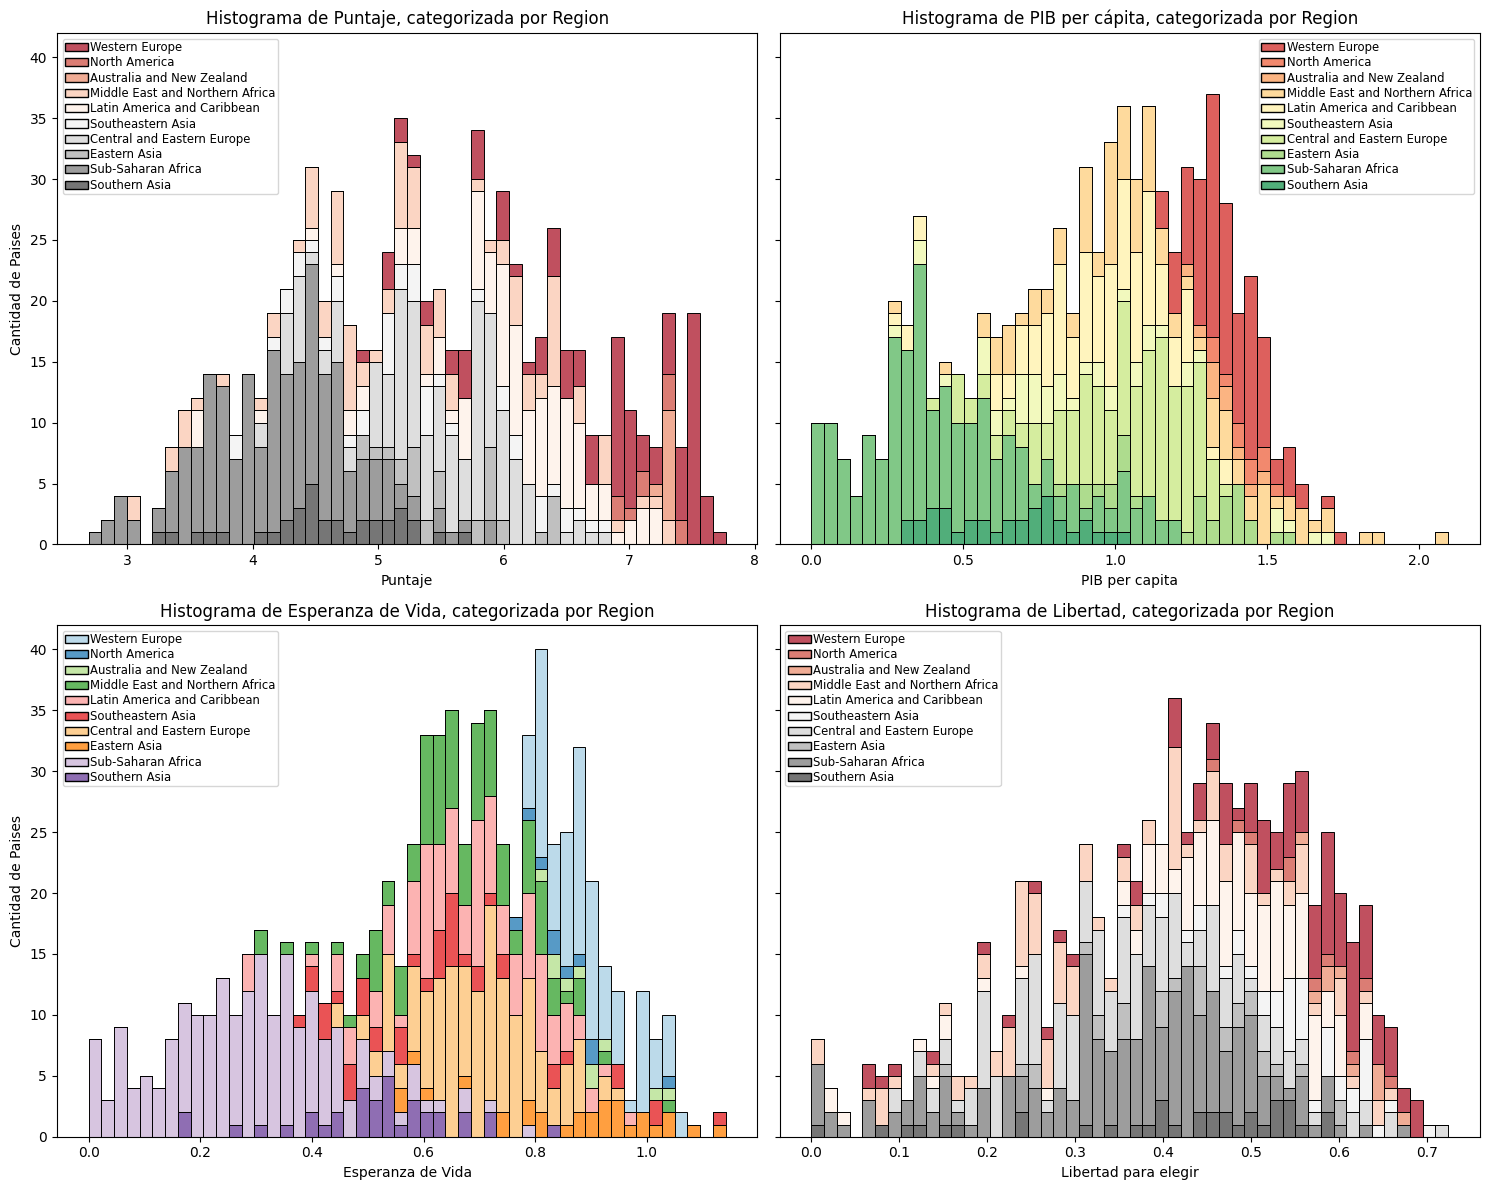

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharey = True)

#las paletas de colores las saque de https://www.practicalpythonfordatascience.com/ap_seaborn_palette
#usare distintas paletas de colores como un ejercicio aunque idealmente debiese ser una misma paleta o similar dependiendo de los resultados mostrados

sns.histplot(data=df, x='Puntaje_Felicidad', bins=50, ax=axes[0, 0], hue='Region', palette='RdGy', multiple='stack')
sns.histplot(data=df, x='PIBpc', bins=50, ax=axes[0, 1], hue='Region', palette='RdYlGn', multiple='stack')
sns.histplot(data=df, x='Esperanza_Vida', bins=50, ax=axes[1, 0], hue='Region', palette='Paired', multiple='stack')
sns.histplot(data=df, x='Libertad', bins=50, ax=axes[1, 1], hue='Region', palette='RdGy', multiple='stack')

#titulos
axes[0, 0].set_title('Histograma de Puntaje, categorizada por Region')
axes[0, 1].set_title('Histograma de PIB per cápita, categorizada por Region')
axes[1, 0].set_title('Histograma de Esperanza de Vida, categorizada por Region')
axes[1, 1].set_title('Histograma de Libertad, categorizada por Region')

#ejes
axes[0, 0].set_xlabel('Puntaje')
axes[0, 0].set_ylabel('Cantidad de Paises')
axes[1, 0].set_ylabel('Cantidad de Paises')
axes[0, 1].set_xlabel('PIB per capita')
axes[1, 0].set_xlabel('Esperanza de Vida')
axes[1, 1].set_xlabel('Libertad para elegir')

#movemos la leyenda para que tape la menor cantidad de datos posibles
sns.move_legend(axes[0, 0], "upper left", title=None, fontsize='small', labelspacing=0.2, handletextpad=0.2, borderpad=0.2)
sns.move_legend(axes[0, 1], "upper right", title=None, fontsize='small', labelspacing=0.2, handletextpad=0.2, borderpad=0.2)
sns.move_legend(axes[1, 0], "upper left", title=None, fontsize='small', labelspacing=0.2, handletextpad=0.2, borderpad=0.2)
sns.move_legend(axes[1, 1], "upper left", title=None, fontsize='small', labelspacing=0.2, handletextpad=0.2, borderpad=0.2)

plt.tight_layout()
plt.show()

---
* Si bien podemos estar repitiendo paises en el recuento, la tendencia general debiese mantenerse constante
* la categoria de Region muestra como cada barra se compone
* Podemos ver que en Puntaje de Felicidad, 'Eastern Asia' tiene un rango que va de 3 5.5 aprox, mientras que 'Western Europe' comienza en 5 y termina en 8. Podemos ver la heteogeneidad de America Latina. 'North America' son basicamente Estados Unidos y Canada, asi que por eso aparecen entre 7 y 8.
* El grafico de PIB per capita muestra resultados similares al de Puntaje de Felicidad, aunque se ven unos paises con un PIB per capita mas alto, de "Middle East and North Africa" que podrian ser los productores de petroleo.
* El grafico de esperanza de vida muestra que los valores menores se concentran en "Sub-saharan Africa" mientras los mayores valores en "Western Europe"
* El grafico de Libertad para Elegir muestra alta heterogeneidad en la distribucion en todas las regiones
---

## Crear Boxplots:
* Crea boxplots para las mismas variables para visualizar la mediana, el rango intercuartil y los valores atípicos.
* Personaliza los boxplots con diferentes colores y estilos.

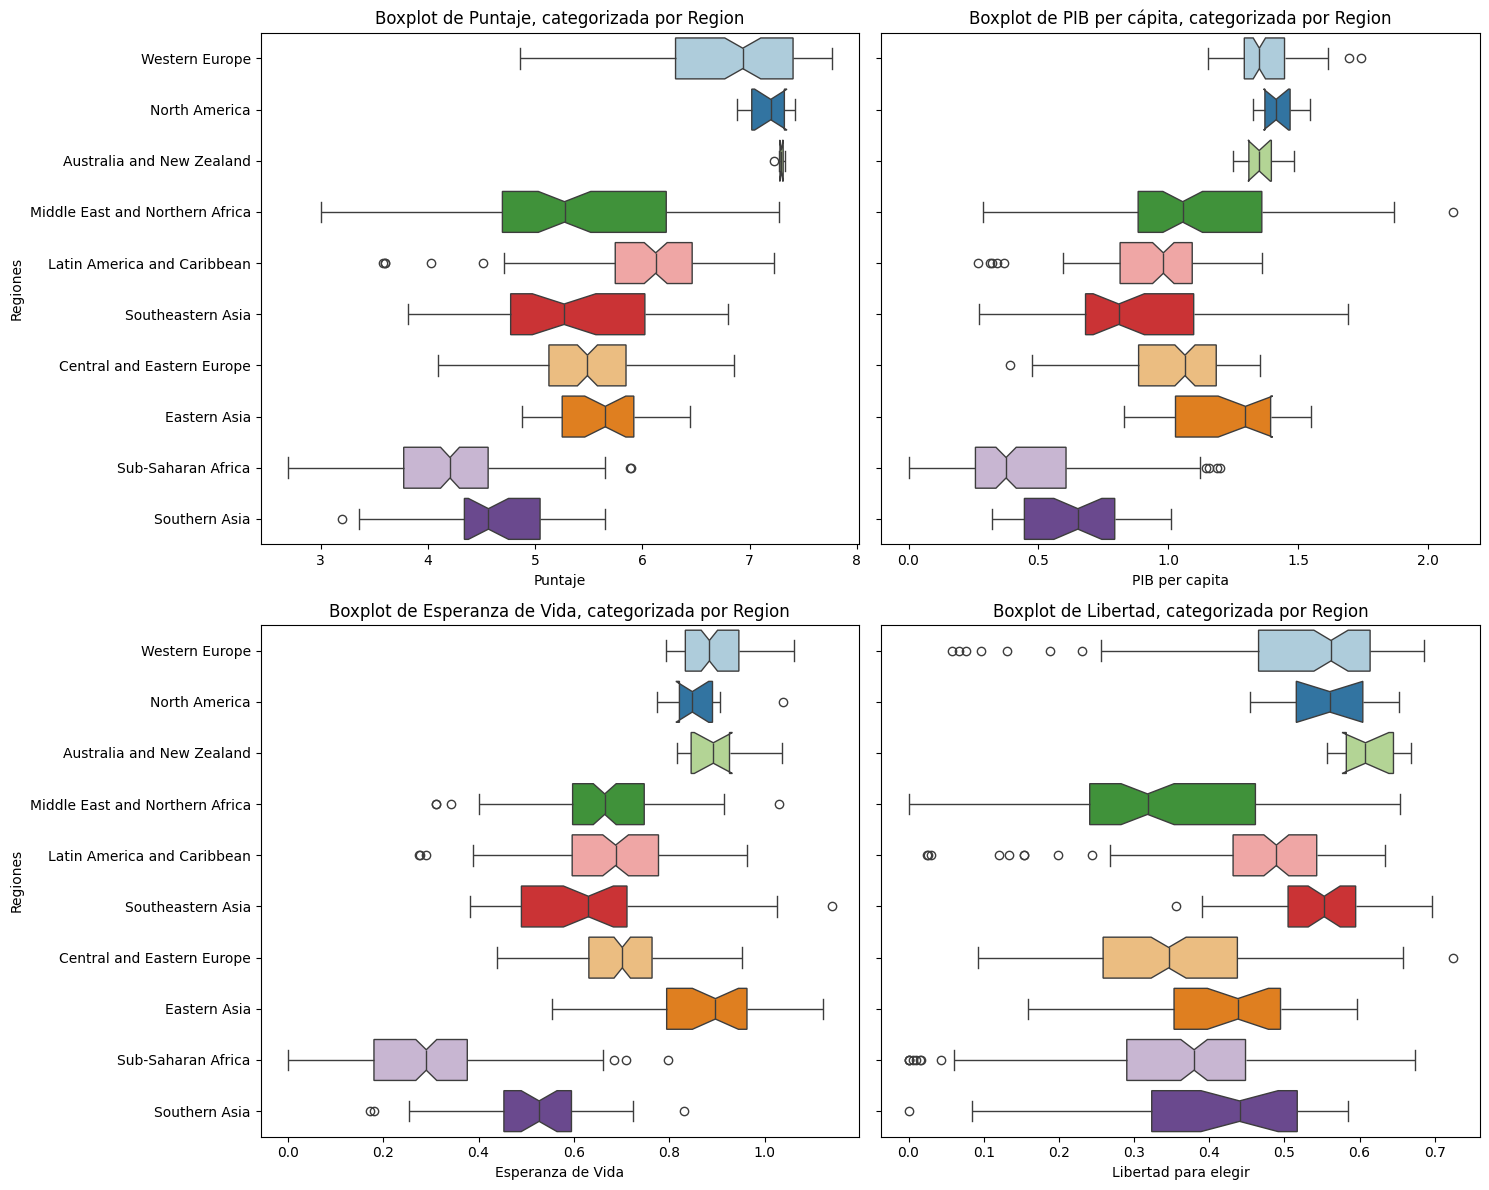

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharey = True)

#las paletas de colores las saque de https://www.practicalpythonfordatascience.com/ap_seaborn_palette
#usare distintas paletas de colores como un ejercicio aunque idealmente debiese ser una misma paleta o similar dependiendo de los resultados mostrados

sns.boxplot(data=df, x='Puntaje_Felicidad', y='Region',hue='Region', ax=axes[0, 0], palette='Paired', notch=True)
sns.boxplot(data=df, x='PIBpc', y='Region',hue='Region', ax=axes[0, 1], palette='Paired', notch=True)
sns.boxplot(data=df, x='Esperanza_Vida', y='Region',hue='Region', ax=axes[1, 0], palette='Paired', notch=True)
sns.boxplot(data=df, x='Libertad', y='Region',hue='Region', ax=axes[1, 1], palette='Paired', notch=True)

#titulos
axes[0, 0].set_title('Boxplot de Puntaje, categorizada por Region')
axes[0, 1].set_title('Boxplot de PIB per cápita, categorizada por Region')
axes[1, 0].set_title('Boxplot de Esperanza de Vida, categorizada por Region')
axes[1, 1].set_title('Boxplot de Libertad, categorizada por Region')

#ejes
axes[0, 0].set_xlabel('Puntaje')
axes[0, 0].set_ylabel('Regiones')
axes[1, 0].set_ylabel('Regiones')
axes[0, 1].set_xlabel('PIB per capita')
axes[1, 0].set_xlabel('Esperanza de Vida')
axes[1, 1].set_xlabel('Libertad para elegir')

plt.tight_layout()
plt.show()

---
* Los outliers se observan de mejor manera en estos boxplots
* Si bien "Middle East and Northern Africa" muestra amplios rangos en todos los graficos, excepto en Esperanza de Vida donde se muestra en la zona superior del grafico
* "Latin America and the Caribbean" debe ser de las zonas mas heterogeneas del mundo, presentando outliers en todos los graficos
* "Sub-Saharan Africa" y "Souther Asia" tienen los puntajes mas bajos, exceptuando el Libertad para elegir donde presentan un amplio rango de valores, ademas de algunos outliers
---

## Análisis Combinado:
* Combina los histogramas y los boxplots en una sola figura para cada variable.
* Interpreta los resultados y escribe un análisis sobre la distribución de cada variable y la presencia de valores atípicos.

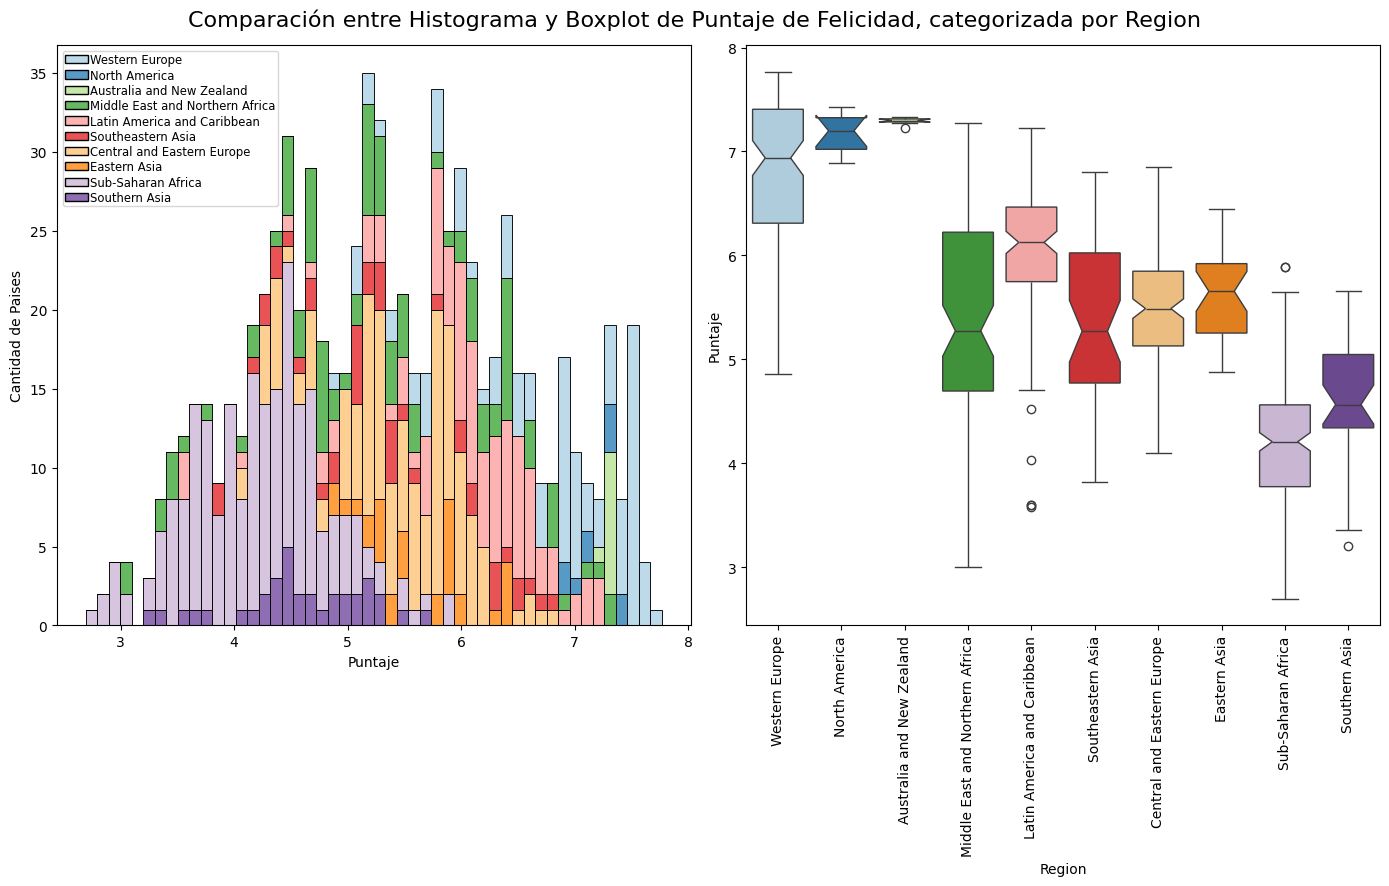

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
plt.suptitle('Comparación entre Histograma y Boxplot de Puntaje de Felicidad, categorizada por Region', fontsize=16)

sns.histplot(data=df, x='Puntaje_Felicidad', bins=50, ax=axes[0], hue='Region', palette='Paired', multiple='stack')
sns.boxplot(data=df, x='Region', y='Puntaje_Felicidad',hue='Region', ax=axes[1], palette='Paired', notch=True)

#giramos los nombres de las regiones para que puedan leerse
axes[1].tick_params(axis='x', rotation=90)

axes[0].set_xlabel('Puntaje')
axes[0].set_ylabel('Cantidad de Paises')
axes[1].set_ylabel('Puntaje')

sns.move_legend(axes[0], "upper left", title=None, fontsize='small', labelspacing=0.2, handletextpad=0.2, borderpad=0.2)

plt.tight_layout()
plt.show()

---
### Distribución del Puntaje de Felicidad:

* 'Eastern Asia' tiene un rango que va de 3 5.5 aprox, mientras que 'Western Europe' comienza en 5 y termina en 8. 
* El histograma nos muestra una alta heteogeneidad en el puntaje de America Latina. El boxplot muestra como outliers los puntajes mas bajos de esa region
* 'North America' son basicamente Estados Unidos y Canada, y "Australia y New Zealand" dicen los nombres de quienes lo conforman, por eso sus boxplots son menores, y su puntaje se mueve entre 7 y 8.
* 'Middle East and Norhtern Africa" tiene el mayor rango de distribucion de todas las regiones, al punto que su boxplot no reconoce outliers
* El boxplot nos muestra 3 categorias de paises de acuerdo al Puntaje de Felicidad: Norteamerica, Australia y Europa Occidental a la cabeza, Africa sub-sahariana y la zona Sur de Asia a la cola, y las otras 5 regiones en una categoria intermedia.

---

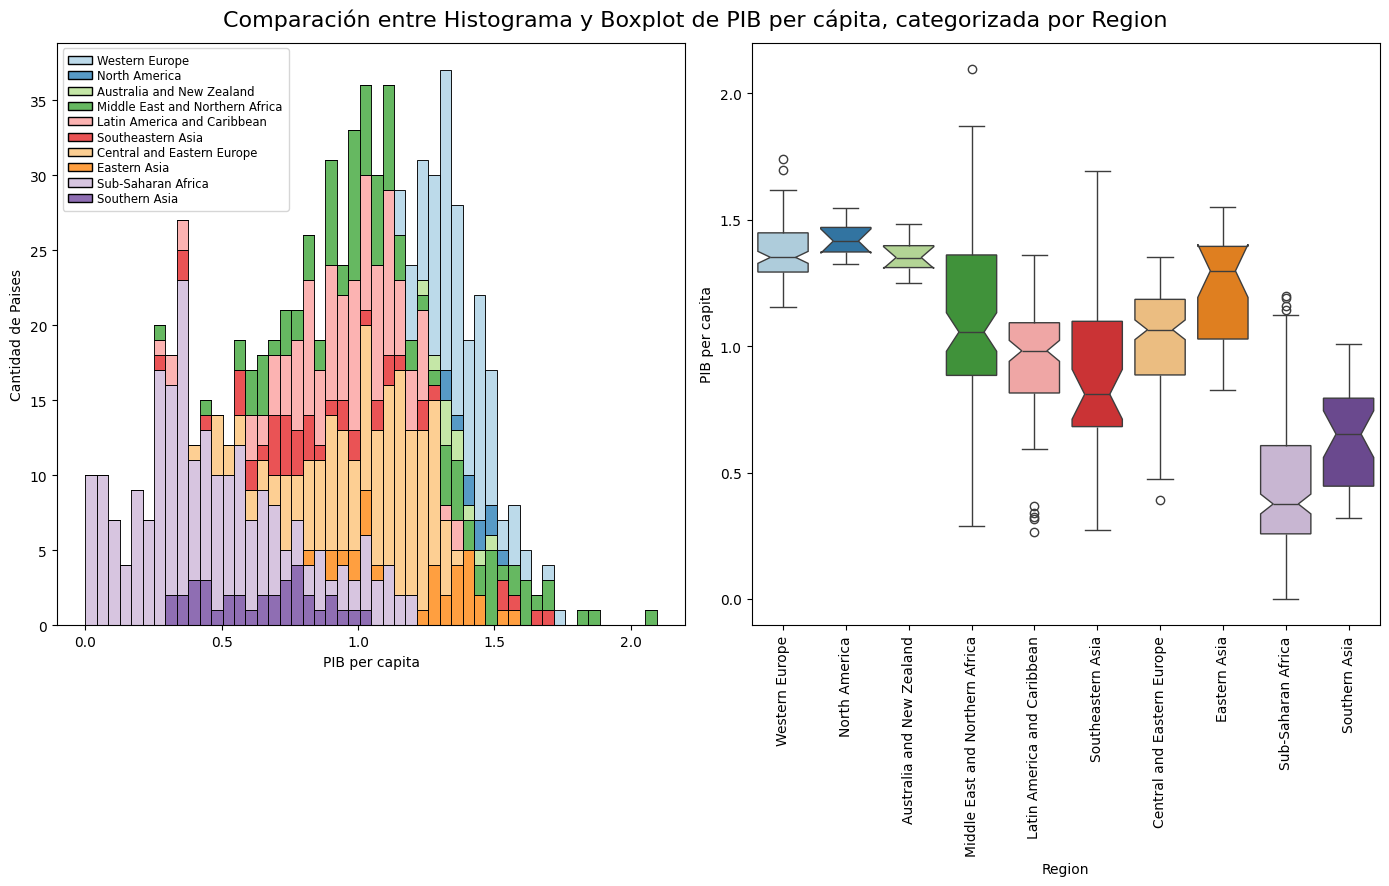

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
plt.suptitle('Comparación entre Histograma y Boxplot de PIB per cápita, categorizada por Region', fontsize=16)


sns.histplot(data=df, x='PIBpc', bins=50, ax=axes[0], hue='Region', palette='Paired', multiple='stack')
sns.boxplot(data=df, x='Region', y='PIBpc',hue='Region', ax=axes[1], palette='Paired', notch=True)

#giramos los nombres de las regiones para que puedan leerse
axes[1].tick_params(axis='x', rotation=90)

axes[0].set_xlabel('PIB per capita')
axes[0].set_ylabel('Cantidad de Paises')
axes[1].set_ylabel('PIB per capita')

sns.move_legend(axes[0], "upper left", title=None, fontsize='small', labelspacing=0.2, handletextpad=0.5, borderpad=0.5)

plt.tight_layout()
plt.show()

---
### Distribución del PIB per capita:

* El grafico de PIB per capita muestra resultados similares al de Puntaje de Felicidad, sin embargo, las categorias que en el grafico anterior se observan claramente en sus boxplots, aca se difuminan
* Si bien, podriamos decir que Europa Occidental, Norteamerica y Australia, se mantiene a la cabeza, "Middle East and Northern Africa" aparecen como la region con los paises con mayores valores, abarcando casi la totalidad de la distribución del gráfico
* Resulta interesante el caso de "Sub-Saharan Africa" que tiene los puntajes de felicidad mas bajos, sin embargo, vemos paises con PIB per capita que pueden compararse a Europa Occidental. o bien, SudAfrica se sale tanto del mapa sus valores aumentan los rangos intercuartiles, o son varios paises los que suben el PIB de esa region


---

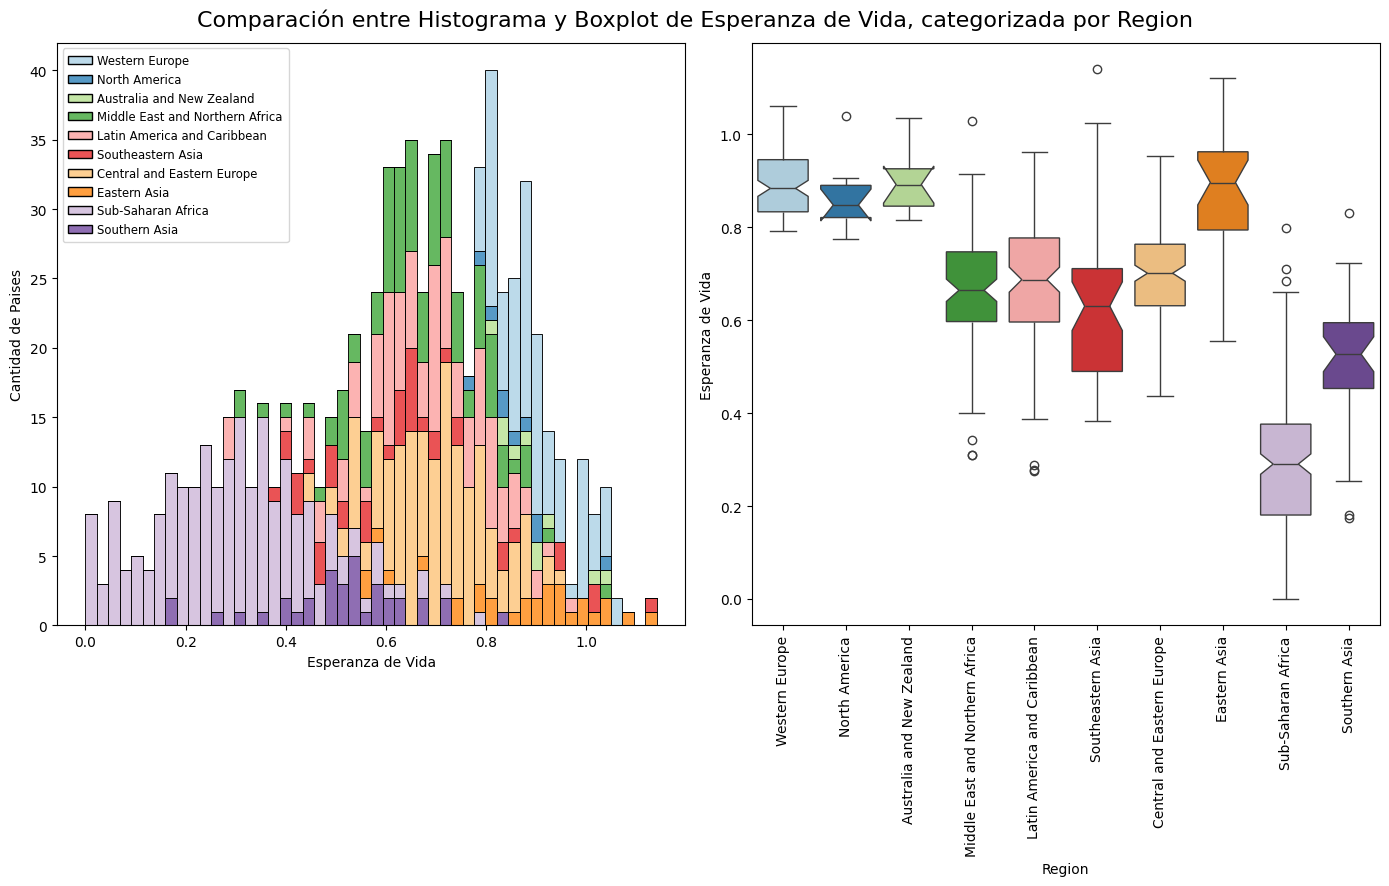

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
plt.suptitle('Comparación entre Histograma y Boxplot de Esperanza de Vida, categorizada por Region', fontsize=16)


sns.histplot(data=df, x='Esperanza_Vida', bins=50, ax=axes[0], hue='Region', palette='Paired', multiple='stack')
sns.boxplot(data=df, x='Region', y='Esperanza_Vida',hue='Region', ax=axes[1], palette='Paired', notch=True)

#giramos los nombres de las regiones para que puedan leerse
axes[1].tick_params(axis='x', rotation=90)

axes[0].set_xlabel('Esperanza de Vida')
axes[0].set_ylabel('Cantidad de Paises')
axes[1].set_ylabel('Esperanza de Vida')

sns.move_legend(axes[0], "upper left", title=None, fontsize='small', labelspacing=0.5, handletextpad=0.5, borderpad=0.5)

plt.tight_layout()
plt.show()

---
### Distribución de Esperanza de Vida:

* Aparece nuevamente las 3 categorias entre las distintas regiones: Norteamerica, Australia y Europa Occidental a la cabeza, Africa sub-sahariana a la cola, y las otras regiones en una categoria intermedia.
* Sin embargo, vemos mejores valores para 'Eastern Asia' y 'Southern Asia'. Asia Oriental (China, Japon, Korea) tienen una mediana similar a la Europea en expectativa de vida.
* 'Southern Asia' tiene mejores valores, aunque posee outliers en ambos extremos del boxplot.
* Segun muestra el histograma, en 'Southeastern Asia', vemos que cerca del valor 0.8, esa Region no existe, dejando dos grupos, uno de naciones con mejores esperanzas de vida y otro con peores.



---

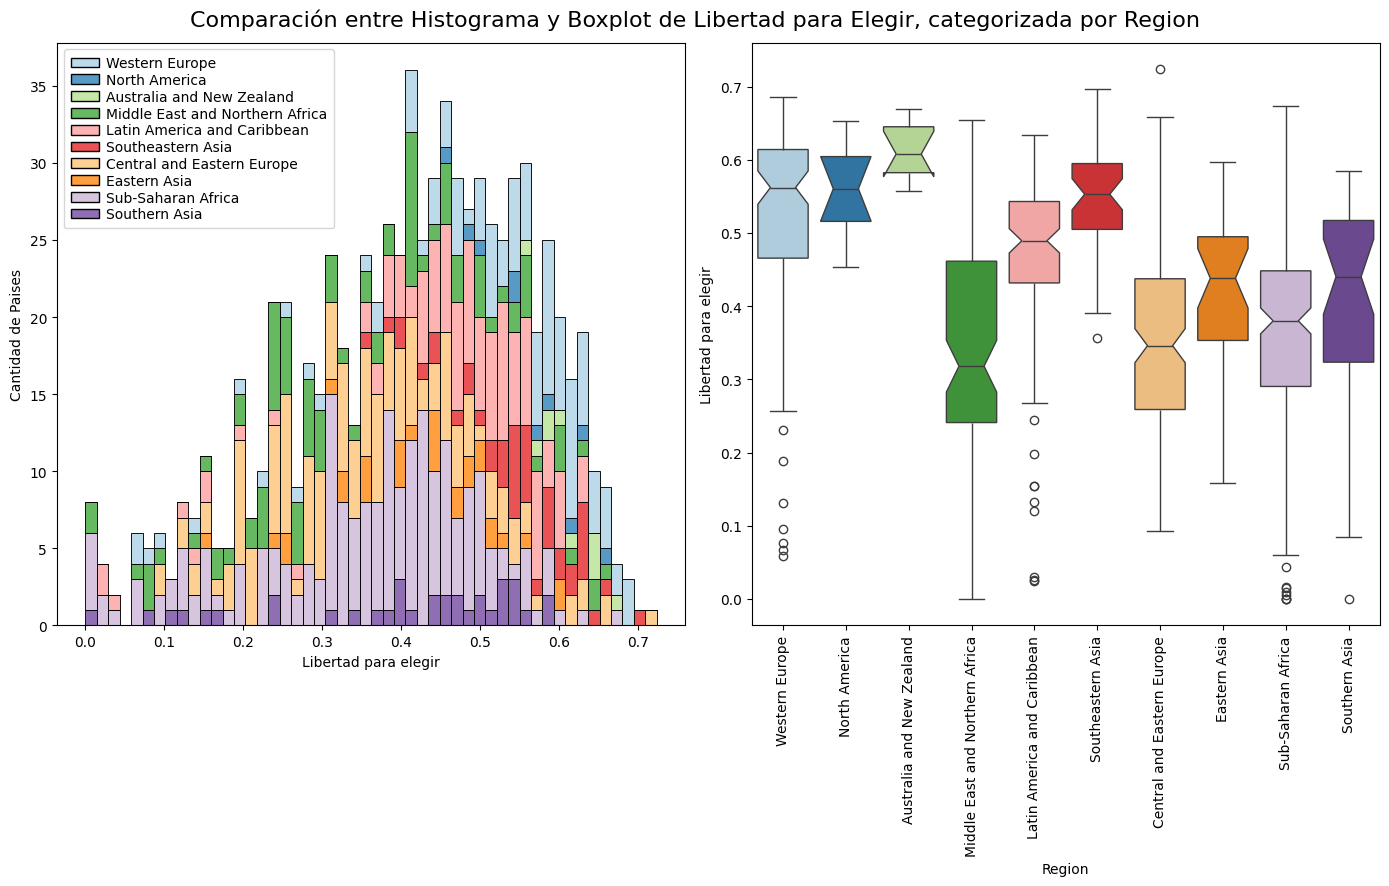

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
plt.suptitle('Comparación entre Histograma y Boxplot de Libertad para Elegir, categorizada por Region', fontsize=16)

sns.histplot(data=df, x='Libertad', bins=50, ax=axes[0], hue='Region', palette='Paired', multiple='stack')
sns.boxplot(data=df, x='Region', y='Libertad',hue='Region', ax=axes[1], palette='Paired', notch=True)

#giramos los nombres de las regiones para que puedan leerse
axes[1].tick_params(axis='x', rotation=90)

axes[0].set_xlabel('Libertad para elegir')
axes[0].set_ylabel('Cantidad de Paises')
axes[1].set_ylabel('Libertad para elegir')

sns.move_legend(axes[0], "upper left", title=None, labelspacing=0.2, handletextpad=0.5, borderpad=0.5)

plt.tight_layout()
plt.show()

---
### Distribución de Libertad para Elegir:

* Aca se observan los mayores rangos de distribucion, y especificamente en zonas con muchos paises, como Europa Occidental, Latinoamerica y Africa Sub-sahariana, aparecen varios ouliers en los boxplots
* Si bien, "Western Europe", "North America" y "Australia and New Zealand" siguen a la cabeza en las mediciones, "Southeast Asia" se pega una subida en esta variable, estando similar a "North America".
* Si bien "Sub-Saharan Africa" se ha encontrado en la cola de otras variables, aca se observa un amplio rango de valores para los paises que la componen. Sin en esperanza de vida existen outliers en puntos superiores, aca vemos varios outliers en puntos inferiores.
* Al igual que en PIB per capita, vemos un amplio rango en "Middle East and Northern Africa" en la libertad para elegir, causado por la diversidad de paises y culturas que incorpora esta región. 



---

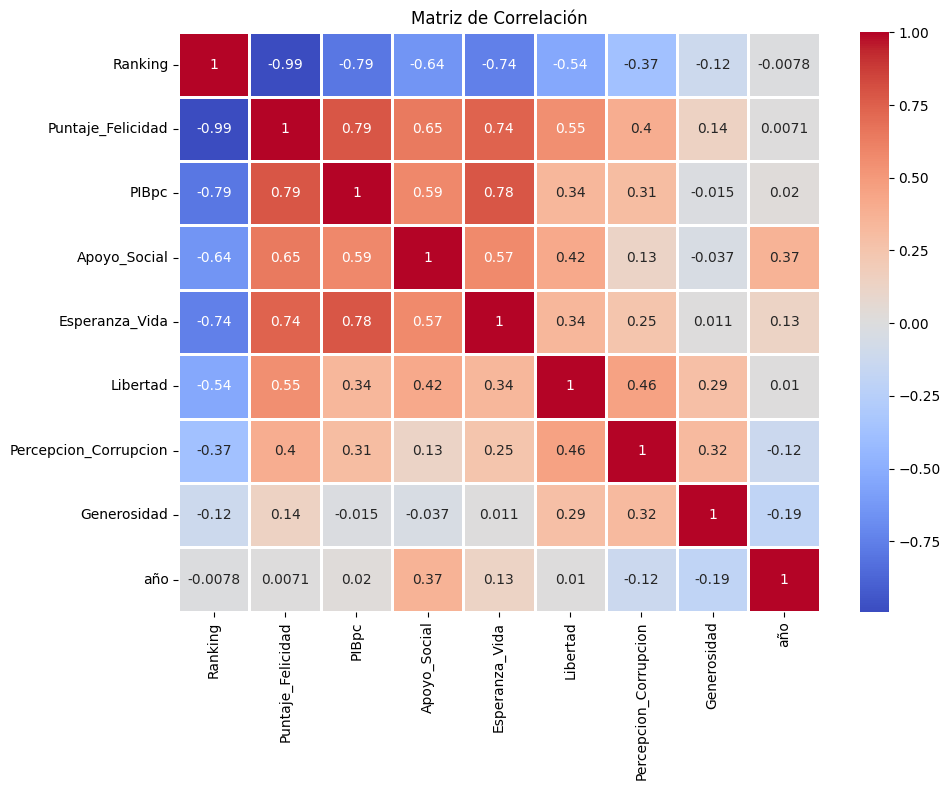

In [30]:
plt.figure(figsize=(10, 8))
plt.title('Matriz de Correlación')
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.8)

plt.tight_layout()


---
### Matriz de correlacion
* Por ultimo queria ver como diversas categorias se relacionaban entre ellas, asi que cree este heatmap para observarlos
* El Puntaje de la Felicidad parece que esta detemrminado principalmente por dos variables: PIB per capita y Esperanza de Vida; y luego vienen Apoto Social (anteriormente Familia) y Libertad de elección.
* Vemos que generosidad (hacer algo por los demas, voluntariado y afines) es la columna que menos se correlacion con el resto. Solo se muestra una leve correlacion positiva con "Percepcion de Corrupcion" y "Libertad de Eleccion"

---